In [2]:
import notebook_setup
import matplotlib.pyplot as plt
import numpy as np
import json

from src.plot_style import set_plot_style
from plot_utils import create_figure
from plot_config import get_colors, get_marker

set_plot_style()

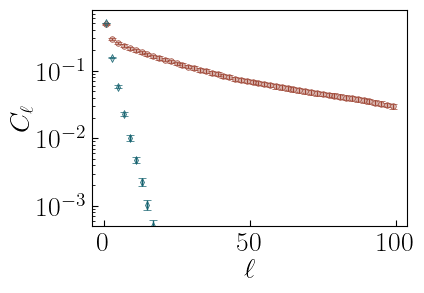

In [3]:
fig, ax = create_figure(8.0, 5.5, margin_cm=2.0)

step = 2 
x = np.arange(1, 100 + 1)
V_values = np.array([5.875, 2.000])

for V in V_values:
    colors = get_colors(V)
    colors_soft = get_colors(V, alpha=0.3)
    marker = get_marker(V)
    correlations_mean = np.load(f'figures_data/correlations_central_spins_V_{V:.3f}_num_sites_{20}.npy')
    correlations_err = np.load(f'figures_data/errors_central_spins_V_{V:.3f}_num_sites_{20}.npy')
    ax.plot(x[::step], correlations_mean[::step], marker=marker, markersize=4.0, markeredgewidth=0.5, lw=0.0, markerfacecolor=colors_soft[-1], markeredgecolor=colors[-1])
    ax.errorbar(x[::step], correlations_mean[::step],yerr=correlations_err[::step], fmt='none', capsize=3.0, linewidth=1, capthick=0.5, color=colors[-1], zorder=1)

ax.set_xlabel(r"$\ell$", fontsize=20, labelpad=2.0)
ax.set_ylabel(r"$C_\ell$", fontsize=20, labelpad=2.0)    
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.set_yscale("log")
ax.set_ylim(bottom=1e-3/2, top=1e-1*8)
plt.savefig("figures/svg/fig4_a.svg", dpi=300, transparent=True)
plt.savefig("figures/pdf/fig4_a.pdf", dpi=300, transparent=True)
plt.show()

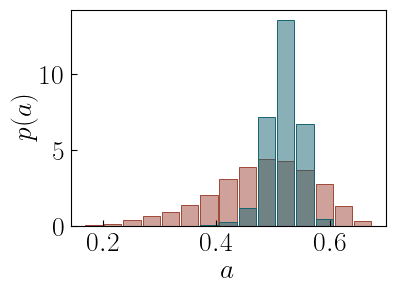

In [4]:
fig, ax = create_figure(8.0, 5.5, margin_cm=2.0)

with open("figures_data/activity_histogram_data.json") as f:
    data = json.load(f)

num_bins = data["num_bins_default"]
datasets = data["data"]

all_a = np.concatenate([np.repeat(d["activities"], d["counts"])for d in datasets.values()])

bins = np.linspace(all_a.min(), all_a.max(), num_bins + 1)
bin_width = bins[1] - bins[0]

V_values = np.array([5.875, 2.000])

for V in V_values:
# for key, d in datasets.items():
    # a = np.array(d["activities"])
    # w = np.array(d["counts"]) / np.sum(d["counts"])
    a = np.array(datasets[f"V_{V:.3f}"]["activities"])
    w = np.array(datasets[f"V_{V:.3f}"]["counts"]) / np.sum(datasets[f"V_{V:.3f}"]["counts"])

    hist, edges = np.histogram(a, bins=bins, weights=w, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    colors = get_colors(V)
    colors_soft = get_colors(V, alpha=0.5)
    plt.bar(centers, hist, width=0.9 * bin_width, lw=0.7, color=colors_soft[-1], edgecolor=colors[-1])

plt.xlabel(r"$a$", fontsize=20, labelpad=2.0)
plt.ylabel(r"$p(a)$", fontsize=20, labelpad=2.0)
plt.xticks([0.2, 0.4, 0.6], fontsize=20)
plt.yticks([0, 5, 10], fontsize=20)

plt.savefig("figures/svg/fig4_b.svg", dpi=300, transparent=True)
plt.savefig("figures/pdf/fig4_b.pdf", dpi=300, transparent=True)
plt.show()